## 1. Dataset Understanding ##

In [1]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset("titanic")

In [2]:
df.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.tail(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [4]:
row, column = df.shape
print(f"Rows = {row} \nColumns = {column}")

Rows = 891 
Columns = 15


In [5]:
#for col in df.columns:
#     print(col)
print(list(df.columns))

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [6]:
print(df.dtypes)

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object


In [7]:
df.describe().round(2)

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [8]:
numeric_col = df.select_dtypes(include=["number"]).columns
print("numeric",numeric_col)
category_col = df.select_dtypes(include=["category", "string", "bool"]).columns
print("category", category_col)

numeric Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare'], dtype='str')
category Index(['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')


## 2. Data Quality ##

In [9]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [10]:
# percentage = (df.isnull().sum() / df.shape[0]) * 100
percentage = df.isnull().mean() * 100


In [11]:
print (percentage.round(2))

survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64


In [12]:
df.nunique()

survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64

In [13]:
df.duplicated().value_counts()

False    784
True     107
Name: count, dtype: int64

In [14]:
df.columns[df.nunique() < len(df)]

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [15]:
duplicate_row = df[df.duplicated()]
print(duplicate_row)

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
47          1       3  female   NaN      0      0   7.7500        Q   Third   
76          0       3    male   NaN      0      0   7.8958        S   Third   
77          0       3    male   NaN      0      0   8.0500        S   Third   
87          0       3    male   NaN      0      0   8.0500        S   Third   
95          0       3    male   NaN      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
870         0       3    male  26.0      0      0   7.8958        S   Third   
877         0       3    male  19.0      0      0   7.8958        S   Third   
878         0       3    male   NaN      0      0   7.8958        S   Third   
884         0       3    male  25.0      0      0   7.0500        S   Third   
886         0       2    male  27.0      0      0  13.0000        S  Second   

       who  adult_male deck  embark_town alive  alo

In [16]:
df.groupby("survived")["sex"].value_counts()

survived  sex   
0         male      468
          female     81
1         female    233
          male      109
Name: count, dtype: int64

In [17]:
quality_check = pd.DataFrame({
    'type': df.dtypes,
    'missing_%': (df.isnull().mean() * 100).round(1),
    'unique_count': df.nunique()
})
print(quality_check)

                 type  missing_%  unique_count
survived        int64        0.0             2
pclass          int64        0.0             3
sex               str        0.0             2
age           float64       19.9            88
sibsp           int64        0.0             7
parch           int64        0.0             7
fare          float64        0.0           248
embarked          str        0.2             3
class        category        0.0             3
who               str        0.0             3
adult_male       bool        0.0             2
deck         category       77.2             7
embark_town       str        0.2             3
alive             str        0.0             2
alone            bool        0.0             2


In [18]:
df.groupby("survived")["sex"].value_counts()

survived  sex   
0         male      468
          female     81
1         female    233
          male      109
Name: count, dtype: int64

In [19]:
non_use_columns = ["alive", "embark_town", "class", "deck"]
df_use = df.drop(columns=non_use_columns)

In [20]:
df.corr(numeric_only=True).round(1)

,survived,pclass,age,sibsp,parch,fare,adult_male,alone
survived,1.0,-0.3,-0.1,-0.0,0.1,0.3,-0.6,-0.2
pclass,-0.3,1.0,-0.4,0.1,0.0,-0.5,0.1,0.1
age,-0.1,-0.4,1.0,-0.3,-0.2,0.1,0.3,0.2
sibsp,-0.0,0.1,-0.3,1.0,0.4,0.2,-0.3,-0.6
parch,0.1,0.0,-0.2,0.4,1.0,0.2,-0.3,-0.6
fare,0.3,-0.5,0.1,0.2,0.2,1.0,-0.2,-0.3
adult_male,-0.6,0.1,0.3,-0.3,-0.3,-0.2,1.0,0.4
alone,-0.2,0.1,0.2,-0.6,-0.6,-0.3,0.4,1.0


In [21]:
df.skew(numeric_only=True)

survived      0.478523
pclass       -0.630548
age           0.389108
sibsp         3.695352
parch         2.749117
fare          4.787317
adult_male   -0.420431
alone        -0.420431
dtype: float64

In [22]:
def uniqueValue(columns):
    print("unique values", df[columns].unique())

uniqueValue("sex")
uniqueValue("embarked")
uniqueValue("pclass")

print("\nAny negative ages?", (df["age"] < 0).any())
print("Any negative fares?", (df["fare"] < 0).any())
print("Any ages > 100?", (df["age"] > 100).any())

print((df["fare"] == 0).sum())

print(df[(df["age"] < 16) & (df["adult_male"] == True)])

unique values <StringArray>
['male', 'female']
Length: 2, dtype: str
unique values <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str
unique values [3 1 2]

Any negative ages? False
Any negative fares? False
Any ages > 100? False
15
Empty DataFrame
Columns: [survived, pclass, sex, age, sibsp, parch, fare, embarked, class, who, adult_male, deck, embark_town, alive, alone]
Index: []


In [23]:
numeric_cols = df.select_dtypes(include=["number"])

Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier = ((numeric_cols < lower_bound) | (numeric_cols > upper_bound))

outlier_summary = pd.DataFrame({
    "lower bound" : lower_bound.round(2),
    "upper bound" : upper_bound.round(2),
    "outlier count" : outlier.sum(),
    "Outlier %": (outlier.mean() * 100).round(2)
})
print(outlier_summary)

          lower bound  upper bound  outlier count  Outlier %
survived        -1.50         2.50              0       0.00
pclass           0.50         4.50              0       0.00
age             -6.69        64.81             11       1.23
sibsp           -1.50         2.50             46       5.16
parch            0.00         0.00            213      23.91
fare           -26.72        65.63            116      13.02


## 3. Univariate Analysis ##

In [24]:
import matplotlib.pyplot as plt

In [25]:
print(df["age"].describe())
print(df["age"].skew())
print(df["age"].std() / df["age"].mean())

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64
0.38910778230082704
0.4891221855465675


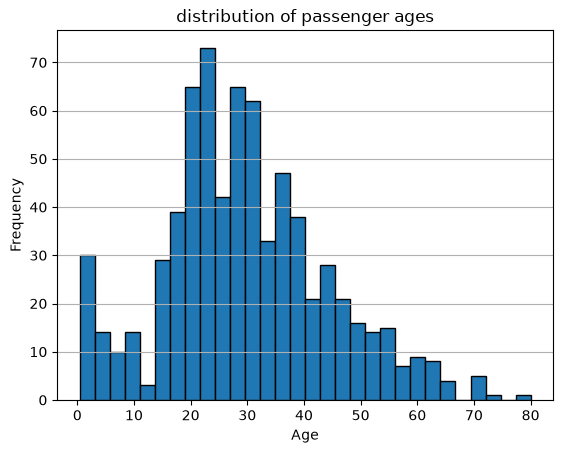

In [26]:
clean_age = df["age"].dropna()

plt.hist(clean_age, bins=30, edgecolor = "black")
plt.title("distribution of passenger ages")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

Text(0.5, 1.0, 'distribution of passenger fares')

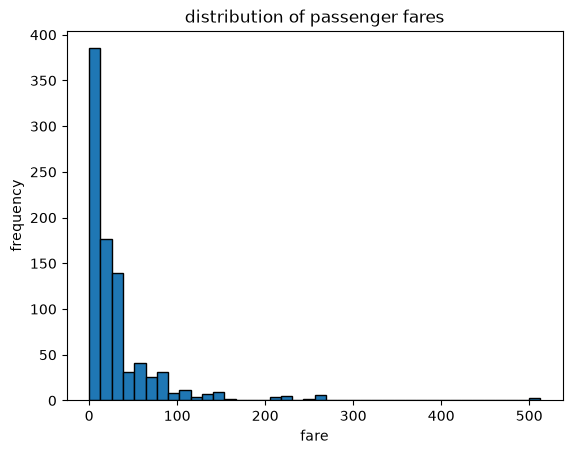

In [27]:
fare_clean = df["fare"].dropna()

plt.hist(fare_clean, bins=40, edgecolor="black")
plt.xlabel("fare")
plt.ylabel("frequency")
plt.title("distribution of passenger fares")

In [28]:
df["sex"].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [29]:
df["class"].value_counts()

class
Third     491
First     216
Second    184
Name: count, dtype: int64

In [30]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [31]:
df["embarked"].value_counts(dropna=False)

embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [32]:
count = df["embarked"].fillna("Missing").value_counts()

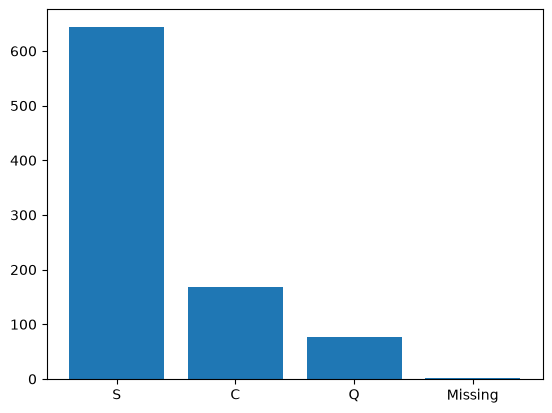

In [33]:
plt.bar(count.index, count.values)
plt.show()

In [34]:
most_common_class = df["pclass"].mode()[0]
print("most common class =", most_common_class)

most common class = 3


In [35]:
most_common_age = df["age"].mode()[0]
print("most common age", most_common_age)

most common age 24.0


## 4. Survival Analysis ##

In [36]:
sPercentage = round(df["survived"].mean() * 100, 2)

print("survived passenger :", sPercentage)

survived passenger : 38.38


In [37]:
nonsPercentage = (df["survived"] == 0).mean()*100
print(nonsPercentage)

61.61616161616161


In [38]:
df.groupby("survived")["sex"].value_counts()

survived  sex   
0         male      468
          female     81
1         female    233
          male      109
Name: count, dtype: int64

In [39]:
df[df["survived"]==1]["sex"].value_counts()

sex
female    233
male      109
Name: count, dtype: int64

In [40]:
df[df["survived"]==1]["pclass"].value_counts()

pclass
1    136
3    119
2     87
Name: count, dtype: int64

In [41]:
df[df["survived"]==1]["embarked"].value_counts()

embarked
S    217
C     93
Q     30
Name: count, dtype: int64

In [42]:
df.groupby("age")["survived"].count()

age
0.42     1
0.67     1
0.75     2
0.83     2
0.92     1
        ..
70.00    2
70.50    1
71.00    2
74.00    1
80.00    1
Name: survived, Length: 88, dtype: int64

In [43]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["child", "Teen", "Young Adult", "adult", "Senior"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

In [44]:
df.groupby("age_group", observed=False)["survived"].mean() * 100

age_group
child          57.971014
Teen           42.857143
Young Adult    38.268156
adult          40.000000
Senior         22.727273
Name: survived, dtype: float64

In [45]:
class_summary = df.groupby("pclass")["survived"].agg(
    Total_passengers="count",
    survivors="sum",
    survive_rate=lambda x: x.mean() * 100
)

In [46]:
print(class_summary)

        Total_passengers  survivors  survive_rate
pclass                                           
1                    216        136     62.962963
2                    184         87     47.282609
3                    491        119     24.236253


## 5. Bivariate Analysis ##

In [47]:
df_corr = df.copy()
df_corr["sex_code"] = df_corr["sex"].map({"female" : 1, "male" : 0})
df_corr["embarked_code"] = df_corr["embarked"].map({"S" : 1, "C" : 2, "Q" : 3})

cols = ["survived", "pclass", "sex_code", "age", "fare", "embarked_code"]
matrix = df_corr[cols].corr()

Text(0.5, 1.0, 'Correlation heatmap with survived')

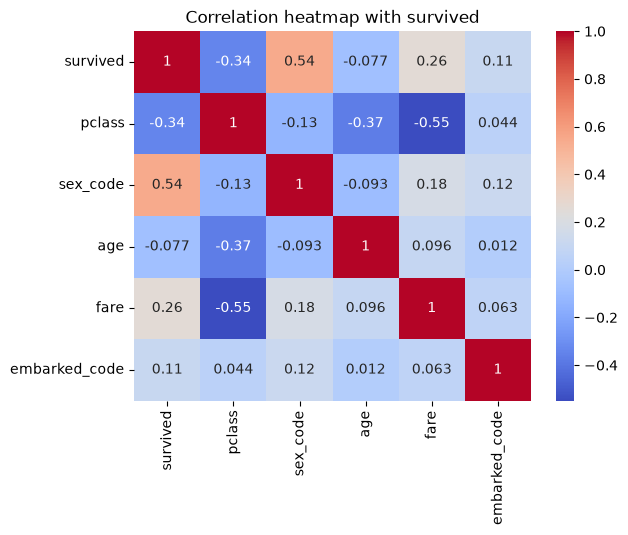

In [48]:
plt.Figure(figsize=(8, 6))

sns.heatmap(matrix, annot=True, cmap="coolwarm")
plt.title("Correlation heatmap with survived")

In [49]:
fare_summary = df.groupby("pclass")["fare"].agg(
        mean = "mean",
        median = "median",
        min = "min",
        max = "max",
        std = "std"
    ).round(2)

In [50]:
print(fare_summary)

         mean  median  min     max    std
pclass                                   
1       84.15   60.29  0.0  512.33  78.38
2       20.66   14.25  0.0   73.50  13.42
3       13.68    8.05  0.0   69.55  11.78


In [51]:
age_passenger_summary = df.groupby("pclass")["age"].agg(
    
    mean = "mean",
    median = "median",
    min = "min",
    max = "max",
    std = "std"
).round(2)
print(age_passenger_summary)

         mean  median   min   max   std
pclass                                 
1       38.23    37.0  0.92  80.0  14.8
2       29.88    29.0  0.67  70.0  14.0
3       25.14    24.0  0.42  74.0  12.5


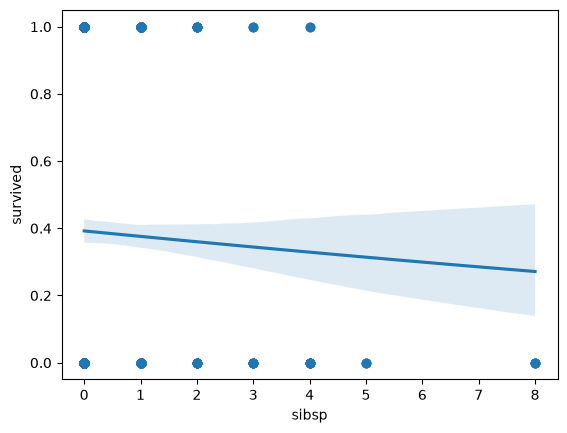

In [52]:
sns.regplot(x="sibsp", y="survived", data=df, logistic=True)
plt.show()

In [53]:
df["parch"].corr(df["survived"])

np.float64(0.08162940708348372)

## 6. Multivariate Analysis ##

In [54]:
survival_plot_S_Pc = df.pivot_table(values="survived", index="pclass", columns="sex", aggfunc="mean")
print(survival_plot_S_Pc)

sex       female      male
pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


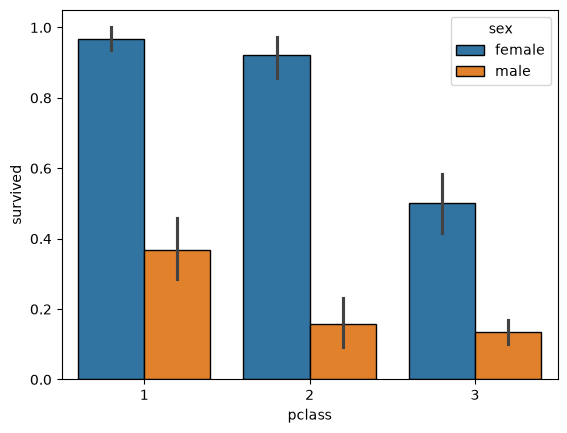

In [55]:
sns.barplot(x="pclass", y="survived", hue="sex", data=df,edgecolor = "black")
plt.show()

In [56]:
survival_plot_s_p_a = df.pivot_table(values="survived", index=["pclass", "age"], columns="sex", aggfunc="mean")
print(survival_plot_s_p_a)

sex           female  male
pclass age                
1      0.92      NaN   1.0
       2.00      0.0   NaN
       4.00      NaN   1.0
       11.00     NaN   1.0
       14.00     1.0   NaN
...              ...   ...
3      61.00     NaN   0.0
       63.00     1.0   NaN
       65.00     NaN   0.0
       70.50     NaN   0.0
       74.00     NaN   0.0

[182 rows x 2 columns]


In [57]:
bins = [0, 12, 18, 60, 100]
labels = ["Child", "Teen", "Adult", "Senior"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)
print(df["age_group"])

0      Adult
1      Adult
2      Adult
3      Adult
4      Adult
       ...  
886    Adult
887    Adult
888      NaN
889    Adult
890    Adult
Name: age_group, Length: 891, dtype: category
Categories (4, str): ['Child' < 'Teen' < 'Adult' < 'Senior']


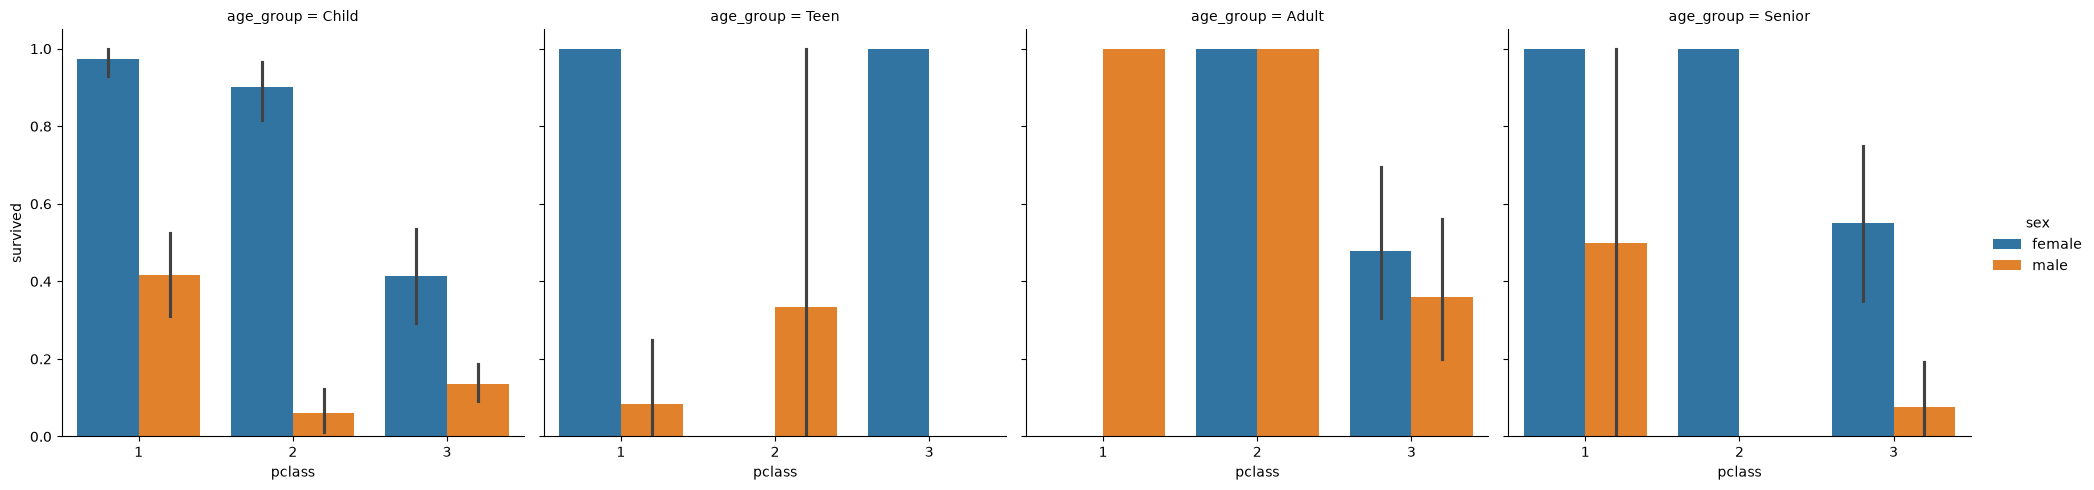

In [58]:
sns.catplot(
    x="pclass",
    y="survived",
    hue="sex",
    col="age_group",
    data=df,
    kind="bar",
)
plt.show()

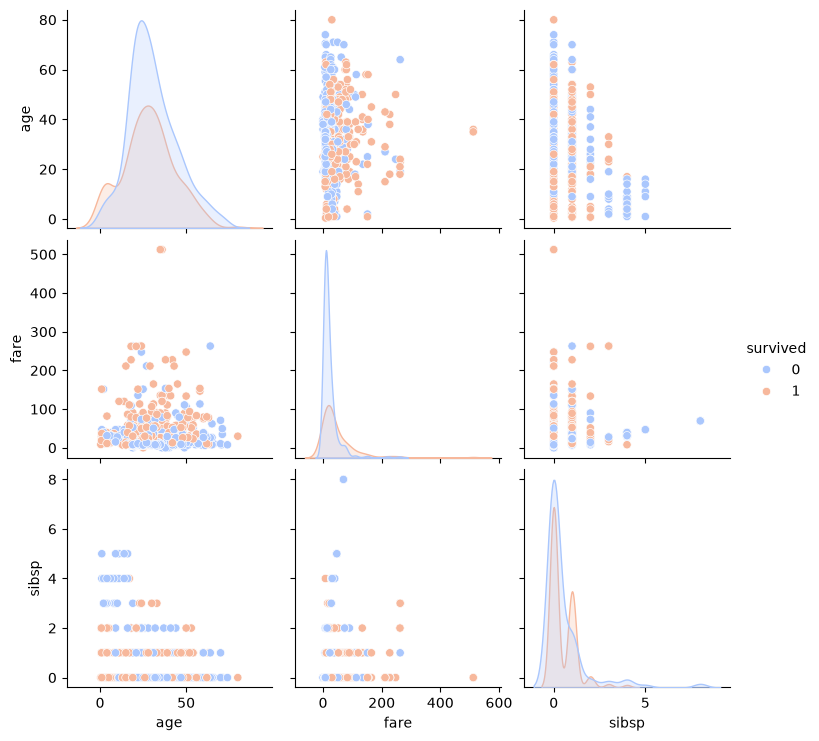

In [59]:
features = ["age", "fare", "sibsp", "survived"]
sns.pairplot(df[features], hue="survived", palette="coolwarm")
plt.show()

In [60]:
port_class_pivot = df.pivot_table(
    values="survived", index="pclass", columns="embarked", aggfunc="mean"
)

print(port_class_pivot)

embarked         C         Q         S
pclass                                
1         0.694118  0.500000  0.582677
2         0.529412  0.666667  0.463415
3         0.378788  0.375000  0.189802


In [63]:
port_age_pivot = df.pivot_table(
    values="survived", index="age_group", columns="sex", aggfunc="mean"
)
print(port_age_pivot)

sex          female      male
age_group                    
Child      0.593750  0.567568
Teen       0.750000  0.088235
Adult      0.778947  0.184573
Senior     1.000000  0.105263


In [64]:
df["sibsp"].value_counts()

sibsp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [69]:
plot_family_count = df.pivot_table(
    values="survived", index="sibsp", columns="sex", aggfunc="mean"
)
print(plot_family_count)

sex      female      male
sibsp                    
0      0.787356  0.168203
1      0.754717  0.310680
2      0.769231  0.200000
3      0.363636  0.000000
4      0.333333  0.083333
5      0.000000  0.000000
8      0.000000  0.000000


In [70]:
df.groupby(["sex", "pclass", "age_group"])["survived"].mean().sort_values(ascending=False)

sex     pclass  age_group
female  1       Teen         1.000000
        2       Child        1.000000
        1       Senior       1.000000
        2       Teen         1.000000
male    2       Child        1.000000
        1       Child        1.000000
female  3       Senior       1.000000
        1       Adult        0.972222
        2       Adult        0.900000
        3       Teen         0.550000
male    1       Teen         0.500000
female  3       Child        0.478261
male    1       Adult        0.416667
female  3       Adult        0.413793
male    3       Child        0.360000
        2       Senior       0.333333
        3       Adult        0.136364
        1       Senior       0.083333
        3       Teen         0.076923
        2       Adult        0.061728
female  1       Child        0.000000
male    2       Teen         0.000000
        3       Senior       0.000000
Name: survived, dtype: float64